TRAINING RANDOM FOREST MODEL FOR XAI ANALYSIS
Best Parameters : {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Accuracy : 0.8421
Precision : 0.8504
Recall : 0.8438
F1 Score : 0.8471


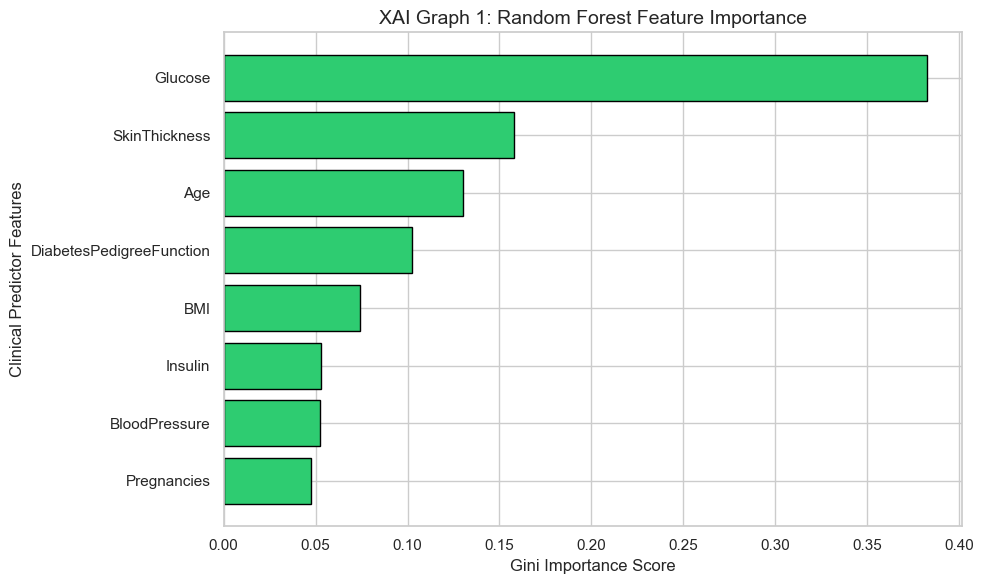


CALCULATING SHAP EXPLANATIONS...


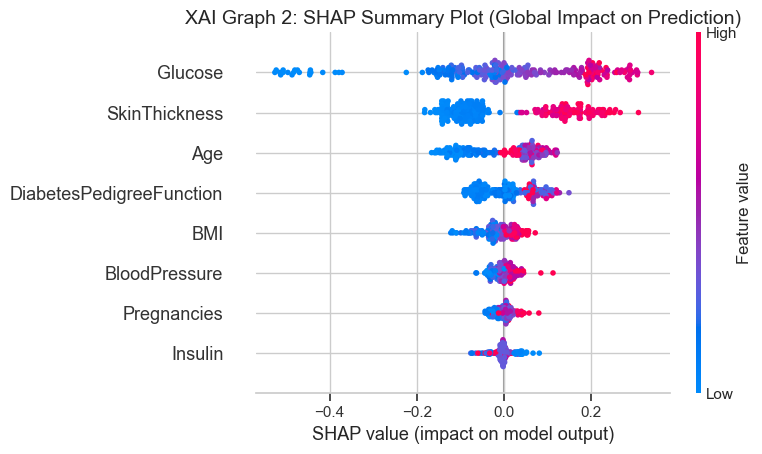

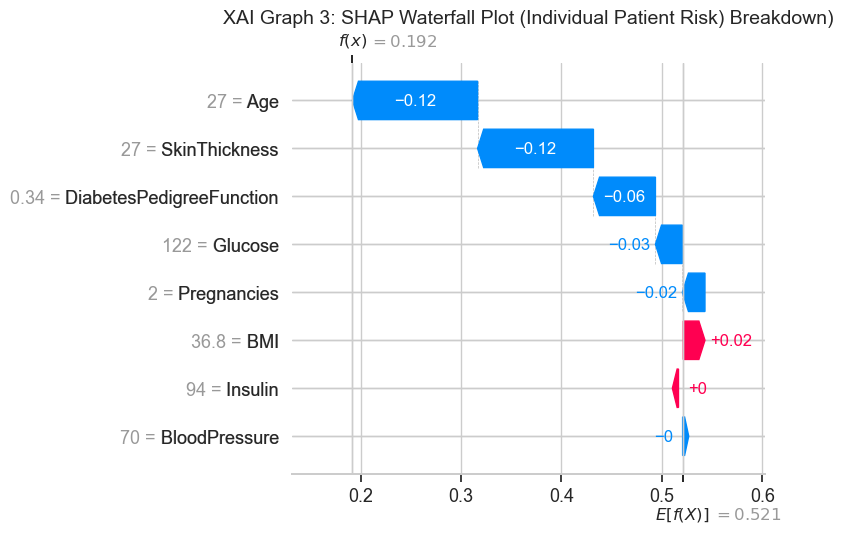

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler


# Step 1: Load Dataset

df = pd.read_csv("diabatess.csv")

# ==========================================
# Step 2: Replace Zeros with Median
# ==========================================
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_cols:
    median = df[df[col] != 0][col].median()
    df[col] = df[col].replace(0, median)

# ==========================================
# Step 3: Features and Target
# ==========================================
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# ==========================================
# Step 4: Train Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)


# Step 5: Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 6: Hyperparameter Grid

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

print("TRAINING RANDOM FOREST MODEL FOR XAI ANALYSIS")


grid_no = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1,
)
grid_no.fit(X_train_scaled, y_train)

best_no = grid_no.best_estimator_
pred_no = best_no.predict(X_test_scaled)

print("Best Parameters :", grid_no.best_params_)
print("Accuracy :", round(accuracy_score(y_test, pred_no), 4))
print("Precision :", round(precision_score(y_test, pred_no), 4))
print("Recall :", round(recall_score(y_test, pred_no), 4))
print("F1 Score :", round(f1_score(y_test, pred_no), 4))


sns.set_theme(style="whitegrid")


# XAI GRAPH 1: FEATURE IMPORTANCE GRAPH 

importances = best_no.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"],
    color="#2ecc71",
    edgecolor="black",
)
plt.xlabel("Gini Importance Score", fontsize=12)
plt.ylabel("Clinical Predictor Features", fontsize=12)
plt.title("XAI Graph 1: Random Forest Feature Importance", fontsize=14)
plt.tight_layout()
plt.savefig(
    "Figure_3_6_feature_imp.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# XAI GRAPH 2 & 3: SHAP SUMMARY AND WATERFALL GRAPH

try:
    import shap

    print("\nCALCULATING SHAP EXPLANATIONS...")

    # TreeExplainer using modern SHAP API
    explainer = shap.TreeExplainer(best_no)
    shap_explanation = explainer(X_test_scaled)

    # Extract Class 1 (Diabetic) SHAP values if binary classification output is 3D
    if len(shap_explanation.shape) == 3:
        shap_exp_class1 = shap_explanation[:, :, 1]
    else:
        shap_exp_class1 = shap_explanation

    # Assign original unscaled feature values and names for clear readable graphs
    shap_exp_class1.data = X_test.values
    shap_exp_class1.feature_names = list(feature_names)

    # XAI GRAPH 2: SHAP SUMMARY PLOT
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_exp_class1, X_test, show=False)
    plt.title(
        "XAI Graph 2: SHAP Summary Plot (Global Impact on Prediction)",
        fontsize=14,
    )
    plt.tight_layout()
    plt.savefig(
    "Figure_3_7_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)
    plt.show()

    # XAI GRAPH 3: SHAP WATERFALL GRAPH FOR AN INDIVIDUAL PATIENT 
    
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_exp_class1[0], show=False)
    plt.title(
        "XAI Graph 3: SHAP Waterfall Plot (Individual Patient Risk)"
        " Breakdown)",
        fontsize=14,
    )
    plt.tight_layout()
    plt.savefig(
    "Figure_3_8_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)
    plt.show()

except ModuleNotFoundError:
    print("\n[Warning] 'shap' library is not installed.")
    print("Run 'pip install shap' in your terminal to enable SHAP graphs.")
except Exception as e:
    print(f"\n[SHAP Plotting Error]: {e}")